In [1]:
import numpy as np
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RANSACRegressor, TheilSenRegressor
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ! unzip phones.zip

Ранее мы посмотрели простой вариант анализа данных, где почти все столбцы имеют численные значения, количество категорий не велико и нет пропусков. Но часто приходится работать с "сырыми" данными, где могут присутствовать текстовые признаки, из которых необходимо извлечь что-то полезное.

Сейчас мы поупражняемся в **Feature Engineering**.

Набор данных содержит информацию о мобильных телефонах. Набор данных взят с сайта [kaggle](https://www.kaggle.com/datasets/demonllord/indian-smartphones-under-20000specs-prices/data).

In [3]:
df = pd.read_csv("indian_smartphones_under_20000_raw.csv", index_col=0)
print("Количество строк: ", len(df))
df.head()

Количество строк:  11976


,Model Name,Price,Percentage Discount,Ratings,Reviews,RAM & ROM,Display Size,Camera,Battery Capacity,Processor,Warranty
0,"vivo T4x 5G (Pronto Purple, 256 GB)",18499.0,11% off,151361.0,7146.0,8 GB RAM | 256 GB ROM,17.07 cm (6.72 inch) Display,50MP + 2MP | 8MP Front Camera,6500 mAh Battery,Dimensity 7300 5G Processor,1 Year Warranty for Device and 6 Months Warran...
1,"MOTOROLA G96 5G (Pantone Ashleigh Blue, 256 GB)",18999.0,17% off,81989.0,4125.0,8 GB RAM | 256 GB ROM,16.94 cm (6.67 inch) Full HD+ Display,50MP + 8MP | 32MP Front Camera,5500 mAh Battery,7s Gen 2 Processor,1 Year Warranty on Handset and 6 Months Warran...
2,"vivo T4x 5G (Pronto Purple, 128 GB)",16499.0,15% off,151361.0,7146.0,8 GB RAM | 128 GB ROM,17.07 cm (6.72 inch) Display,50MP + 2MP | 8MP Front Camera,6500 mAh Battery,Dimensity 7300 5G Processor,1 Year Warranty for Device and 6 Months Warran...
3,"MOTOROLA G96 5G (Pantone Greener Pastures, 256...",18999.0,17% off,81989.0,4125.0,8 GB RAM | 256 GB ROM,16.94 cm (6.67 inch) Full HD+ Display,50MP + 8MP | 32MP Front Camera,5500 mAh Battery,7s Gen 2 Processor,1 Year Warranty on Handset and 6 Months Warran...
4,"realme P4x 5G (Lake Green, 256 GB)",17499.0,16% off,1211.0,125.0,8 GB RAM | 256 GB ROM,17.07 cm (6.72 inch) Full HD+ Display,50MP + 2MP | 8MP Front Camera,7000 mAh Battery,Dimensity 7400 Ultra Processor,1 Year Manufacturer Warranty for Phone and 6 M...


In [4]:
df.drop_duplicates(inplace=True)
print("Количество уникальных строк: ", len(df))

Количество уникальных строк:  823


Во первых, в наборе данных много пустых значений:

In [5]:
df.isna().sum()

Model Name               0
Price                    8
Percentage Discount    100
Ratings                 19
Reviews                 19
RAM & ROM                0
Display Size             0
Camera                   0
Battery Capacity         1
Processor                9
Warranty               218
dtype: int64

Сразу откинем те строки, где нет ценников:

In [6]:
df[df["Price"].isna()]
df = df[df["Price"].notna()]

In [7]:
df.isna().sum()

Model Name               0
Price                    0
Percentage Discount     92
Ratings                 19
Reviews                 19
RAM & ROM                0
Display Size             0
Camera                   0
Battery Capacity         0
Processor                7
Warranty               212
dtype: int64

С другими пропусками мы разберёмся позже.

## Извлечение признаков

Давайте начнём преобразовывать текстовые признаки в числа, которые можно обрабатывать.

Начнём с памяти на устройствах.

In [8]:
df["RAM & ROM"].str.split("|").apply(len).value_counts()

RAM & ROM
3    429
2    386
Name: count, dtype: int64

Есть строчки, делящиеся символом | на 2 и 3 части.

Посмотрим на строчки, где три компоненты, конкретно посмотрим на третью часть:

In [9]:
mask = df["RAM & ROM"].str.split("|").apply(len) == 3
data = df["RAM & ROM"].str.split("|")[mask]

# data
data = data.apply(lambda x: x[2].strip().split(" "))
print("Везде 4 слова:\n\n", data.apply(lambda x: len(x)).value_counts())

words = data.apply(pd.Series)
print(words[0].value_counts())
print(words[1].value_counts())
print(words[2].value_counts())
print(words[3].value_counts())

Везде 4 слова:

 RAM & ROM
4    429
Name: count, dtype: int64
0
Expandable    429
Name: count, dtype: int64
1
Upto    429
Name: count, dtype: int64
2
1       185
2       114
32       44
512      25
256      22
8        16
16       11
128       9
1500      2
64        1
Name: count, dtype: int64
3
TB    299
GB    120
MB     10
Name: count, dtype: int64


Мы узнали, что речь идёт про возможность установки дополнительной памяти. Предпоследнее слово $-$ величина, Последнее слово $-$ единицы измерения.

Теперь разберёмся с первыми двумя компонентами. Проверим, что везде формат `X GB RAM` и `X GB ROM`. Начнём с оперативной памяти:

In [10]:
data = df["RAM & ROM"].str.split("|")


data1 = data.apply(lambda x: x[0].strip().split(" "))
print("Везде 3 слова, но есть и где 4:\n\n", data1.apply(lambda x: len(x)).value_counts())

mask = data1.apply(lambda x: len(x)) == 4
print("Тут снова что-то не так с целыми строчками:")
df[mask]


Везде 3 слова, но есть и где 4:

 RAM & ROM
3    814
4      1
Name: count, dtype: int64
Тут снова что-то не так с целыми строчками:


,Model Name,Price,Percentage Discount,Ratings,Reviews,RAM & ROM,Display Size,Camera,Battery Capacity,Processor,Warranty
324,IAIR Basic Feature Dual Sim Mobile Phone with ...,801.0,52% off,21.0,4.0,0 MB MB ROM | Expandable Upto 32 MB,6.1 cm (2.4 inch) Full HD Display,0.8MP Rear Camera,2800 mAh Battery,1 Years Manufacturer Warranty,NaN


Откинем эту строчку:

In [11]:
data1 = data.apply(lambda x: x[0].strip().split(" "))
mask = data1.apply(lambda x: len(x)) != 4

df = df[mask]

Проверим составляющие:

In [12]:
words = data1.apply(pd.Series)
print(words[1].value_counts())
print("\nГде-то речь не про оперативную память:\n")
print(words[2].value_counts())

1
GB    699
MB    116
Name: count, dtype: int64

Где-то речь не про оперативную память:

2
RAM    809
ROM      5
MB       1
Name: count, dtype: int64


И снова что-то не так с целыми строчками:

In [13]:
mask = words[2] == "ROM"
df[mask]

,Model Name,Price,Percentage Discount,Ratings,Reviews,RAM & ROM,Display Size,Camera,Battery Capacity,Processor,Warranty
328,LAVA A1 Josh,894.0,28% off,9876.0,734.0,0 MB ROM | Expandable Upto 32 GB,4.5 cm (1.77 inch) Quarter QVGA Display,1000 mAh Li-ion Battery,No Warranty,NaN,NaN
376,LAVA A7 Star,1499.0,9% off,21712.0,2241.0,0 GB ROM | Expandable Upto 32 GB,4.5 cm (1.77 inch) Display,0.3MP Rear Camera | 0.3MP Front Camera,1750 mAh Battery,1 year manufacturer Replacement for device and...,NaN
487,IAIR Basic Feature Dual Sim Mobile Phone with ...,799.0,55% off,68.0,16.0,0 MB ROM | Expandable Upto 8 GB,6.1 cm (2.4 inch) Display,0.8MP Rear Camera,2800 mAh Battery,2 Years Manufacturer Warranty,NaN
566,IAIR Basic Feature Dual Sim Mobile Phone with ...,845.0,47% off,41.0,13.0,0 MB ROM | Expandable Upto 32 GB,6.1 cm (2.4 inch) Display,0.8MP Rear Camera,2800 mAh Battery,2 Years Manufacturer Warranty,NaN
573,IAIR Basic Feature Dual Sim Mobile Phone with ...,610.0,59% off,NaN,NaN,0 MB ROM | Expandable Upto 32 GB,4.5 cm (1.77 inch) Display,0.8MP Rear Camera,1000 mAh Battery,2 Years Manufacturer Warranty,NaN


Откинем эти строчки:

In [14]:
mask = words[2] == "RAM"
df = df[mask]


С RAM разобрались, посмотрим на ROM:

In [15]:
data = df["RAM & ROM"].str.split("|")


data1 = data.apply(lambda x: x[1].strip().split(" "))
print("Везде 3 слова, но есть и где 4:\n\n", data1.apply(lambda x: len(x)).value_counts())

mask = data1.apply(lambda x: len(x)) == 4
print("Эта строчка:")
df[mask]


Везде 3 слова, но есть и где 4:

 RAM & ROM
3    808
4      1
Name: count, dtype: int64
Эта строчка:


,Model Name,Price,Percentage Discount,Ratings,Reviews,RAM & ROM,Display Size,Camera,Battery Capacity,Processor,Warranty
449,I Kall K 19 CAr,1305.0,34% off,1771.0,94.0,32 MB RAM | 32 MB/64 MB ROM,4.5 cm (1.77 inch) Display,0.3MP Rear Camera,800 mAh Battery,1 Year warranty for mobile and 6 Months for bo...,NaN


In [16]:
words = data1.apply(pd.Series)
print(words[1].value_counts())
print("\nГде-то речь не про оперативную память:\n")
print(words[2].value_counts())

1
GB       702
MB       105
KB         1
MB/64      1
Name: count, dtype: int64

Где-то речь не про оперативную память:

2
ROM    808
MB       1
Name: count, dtype: int64


Тут аномальная строчка всего одна, её тоже откинем:

In [17]:
mask = data1.apply(lambda x: len(x)) != 4
df = df[mask]

Выделим четыре столбца: размер RAM, ROM, возможность установки дополнительной памяти и её объём. Объём будем измерять в ГБ.

Если дополнительную память установить нельзя введём значение 0. В данном случае корректно обработать данные нам поможет индикаторная переменная, которую мы добавляем. Без такой индикаторной переменной обучаемый вес для размера расширяемой памяти будет искажаться.

In [18]:
def extract_RAM_ROM(x):
    parts = x.split("|")
    result = []
    scale_dict = {"TB":1024, "GB":1, "MB":1/1024, "KB": 1/1024/1024}
    # Извлекаем информацию про RAM
    ram = parts[0].strip().split(" ")
    scale = scale_dict[ram[1]]
    result.append(float(ram[0]) * scale)
    # Извлекаем информацию про ROM
    rom = parts[1].strip().split(" ")
    scale = scale_dict[rom[1]]
    result.append(float(rom[0]) * scale)
    
    if len(parts) == 3:
        external = parts[2].strip().split(" ")
        result.append(True)
        scale = scale_dict[external[-1]]
        result.append(float(external[-2]) * scale)
    else:
        result.append(False)
        result.append(0)
    return result
        
data = df["RAM & ROM"].apply(extract_RAM_ROM)
data

0          [8.0, 256.0, False, 0]
1          [8.0, 256.0, False, 0]
2          [8.0, 128.0, False, 0]
3          [8.0, 256.0, False, 0]
4          [8.0, 256.0, False, 0]
                  ...            
956    [4.0, 128.0, True, 2048.0]
957        [6.0, 128.0, False, 0]
958         [4.0, 64.0, False, 0]
959        [4.0, 128.0, False, 0]
960        [4.0, 128.0, False, 0]
Name: RAM & ROM, Length: 808, dtype: object

In [19]:
data = data.apply(pd.Series)
df["ram"] = data[0]
df["rom"] = data[1]
df["is_extendable"] = data[2]
df["extension_size"] = data[3]
df.head()

,Model Name,Price,Percentage Discount,Ratings,Reviews,RAM & ROM,Display Size,Camera,Battery Capacity,Processor,Warranty,ram,rom,is_extendable,extension_size
0,"vivo T4x 5G (Pronto Purple, 256 GB)",18499.0,11% off,151361.0,7146.0,8 GB RAM | 256 GB ROM,17.07 cm (6.72 inch) Display,50MP + 2MP | 8MP Front Camera,6500 mAh Battery,Dimensity 7300 5G Processor,1 Year Warranty for Device and 6 Months Warran...,8.0,256.0,False,0.0
1,"MOTOROLA G96 5G (Pantone Ashleigh Blue, 256 GB)",18999.0,17% off,81989.0,4125.0,8 GB RAM | 256 GB ROM,16.94 cm (6.67 inch) Full HD+ Display,50MP + 8MP | 32MP Front Camera,5500 mAh Battery,7s Gen 2 Processor,1 Year Warranty on Handset and 6 Months Warran...,8.0,256.0,False,0.0
2,"vivo T4x 5G (Pronto Purple, 128 GB)",16499.0,15% off,151361.0,7146.0,8 GB RAM | 128 GB ROM,17.07 cm (6.72 inch) Display,50MP + 2MP | 8MP Front Camera,6500 mAh Battery,Dimensity 7300 5G Processor,1 Year Warranty for Device and 6 Months Warran...,8.0,128.0,False,0.0
3,"MOTOROLA G96 5G (Pantone Greener Pastures, 256...",18999.0,17% off,81989.0,4125.0,8 GB RAM | 256 GB ROM,16.94 cm (6.67 inch) Full HD+ Display,50MP + 8MP | 32MP Front Camera,5500 mAh Battery,7s Gen 2 Processor,1 Year Warranty on Handset and 6 Months Warran...,8.0,256.0,False,0.0
4,"realme P4x 5G (Lake Green, 256 GB)",17499.0,16% off,1211.0,125.0,8 GB RAM | 256 GB ROM,17.07 cm (6.72 inch) Full HD+ Display,50MP + 2MP | 8MP Front Camera,7000 mAh Battery,Dimensity 7400 Ultra Processor,1 Year Manufacturer Warranty for Phone and 6 M...,8.0,256.0,False,0.0


Далее давайте посмотрим на `Battery Capacity`:

In [20]:
data = df["Battery Capacity"].str.split(" ")
lengths = data.apply(len)
print("Снова разные длины текстов:")

print(lengths.value_counts())

words = data.apply(pd.Series)
# print(words[1].value_counts())
# print("\nГде-то речь не про оперативную память:\n")
print(words[1].value_counts())
mask = words[1] != "mAh"
df[mask]

Снова разные длины текстов:
Battery Capacity
3    672
5     81
4     48
6      4
2      3
Name: count, dtype: int64
1
mAh          802
Months         2
Processor      2
Days           1
Year           1
Name: count, dtype: int64


,Model Name,Price,Percentage Discount,Ratings,Reviews,RAM & ROM,Display Size,Camera,Battery Capacity,Processor,Warranty,ram,rom,is_extendable,extension_size
400,Snexian BOLD 20K PRO,1199.0,40% off,NaN,NaN,32 MB RAM | 32 MB ROM,7.11 cm (2.8 inch) VGA Display,2500 mAh Battery,3 Months Domestic Warranty,NaN,NaN,0.031250,0.031250,False,0.0
436,hmd 105 Dual Sim Keypad Phone with Built-in UP...,950.0,36% off,4322.0,314.0,4 MB RAM | 4 MB ROM | Expandable Upto 32 GB,5.08 cm (2 inch) Display,1000 mAh Battery,SC6531E Processor,1 Year Replacement.,NaN,0.003906,0.003906,True,32.0
474,Nokia 106 Single Sim Keypad Phone with Built-i...,1271.0,25% off,7572.0,406.0,32 MB RAM | 32 MB ROM,17.02 cm (6.7 inch) Display,1000 mAh Battery,SC6531E Processor,1YR BRAND WARRANTY ON HANDSET & 6 MONTHS WARRA...,NaN,0.031250,0.031250,False,0.0
518,Snexian BOLD 777,779.0,48% off,188.0,11.0,32 MB RAM | 32 MB ROM,1.68 cm (0.66 inch) Display,850 mAh Battery,7 Days Warranty,NaN,NaN,0.031250,0.031250,False,0.0
538,I Kall K100,680.0,31% off,10369.0,838.0,32 MB RAM | 32 MB ROM | Expandable Upto 8 GB,4.57 cm (1.8 inch) Display,1000 mAh Battery,12 Months,NaN,NaN,0.031250,0.031250,True,8.0
576,PHILIPS All New E2103 Sleek & Stylish Keypad M...,1139.0,18% off,7.0,1.0,32 MB RAM | 32 MB ROM,4.5 cm (1.77 inch) Display,1000 mAh Battery,One Year manufacturer Warranty,NaN,NaN,0.031250,0.031250,False,0.0


In [21]:
mask = words[1] == "mAh"
df = df[mask]

Давайте проверим каких типов бывают батареи:

In [22]:
data = df["Battery Capacity"].str.split(" ", n=2)
words = data.apply(pd.Series)
words[2].value_counts()

2
Battery                        671
Lithium-ion Polymer Battery     21
Lithium Polymer Battery         17
Lithium Ion Battery             16
Lithium Battery                 14
Li-ion Polymer Battery          12
Lithium-ion Battery              9
Li-ion Battery                   8
Lithium-Ion Polymer Battery      6
Li-polymer Battery               6
Li-Polymer Battery               4
Lithium Ion Polymer Battery      4
Li Polymer Battery               4
Lithium ion Battery              3
Li-Ion Battery                   3
Li-Polymer Battery Battery       1
Lithium polymer Battery          1
Lithium-Ploymer Battery          1
Lithium-polymer Battery          1
Name: count, dtype: int64

In [23]:
df["battery_capacity"] = df["Battery Capacity"].str.split(" ").apply(lambda x: float(x[0]))
df.head()

,Model Name,Price,Percentage Discount,Ratings,Reviews,RAM & ROM,Display Size,Camera,Battery Capacity,Processor,Warranty,ram,rom,is_extendable,extension_size,battery_capacity
0,"vivo T4x 5G (Pronto Purple, 256 GB)",18499.0,11% off,151361.0,7146.0,8 GB RAM | 256 GB ROM,17.07 cm (6.72 inch) Display,50MP + 2MP | 8MP Front Camera,6500 mAh Battery,Dimensity 7300 5G Processor,1 Year Warranty for Device and 6 Months Warran...,8.0,256.0,False,0.0,6500.0
1,"MOTOROLA G96 5G (Pantone Ashleigh Blue, 256 GB)",18999.0,17% off,81989.0,4125.0,8 GB RAM | 256 GB ROM,16.94 cm (6.67 inch) Full HD+ Display,50MP + 8MP | 32MP Front Camera,5500 mAh Battery,7s Gen 2 Processor,1 Year Warranty on Handset and 6 Months Warran...,8.0,256.0,False,0.0,5500.0
2,"vivo T4x 5G (Pronto Purple, 128 GB)",16499.0,15% off,151361.0,7146.0,8 GB RAM | 128 GB ROM,17.07 cm (6.72 inch) Display,50MP + 2MP | 8MP Front Camera,6500 mAh Battery,Dimensity 7300 5G Processor,1 Year Warranty for Device and 6 Months Warran...,8.0,128.0,False,0.0,6500.0
3,"MOTOROLA G96 5G (Pantone Greener Pastures, 256...",18999.0,17% off,81989.0,4125.0,8 GB RAM | 256 GB ROM,16.94 cm (6.67 inch) Full HD+ Display,50MP + 8MP | 32MP Front Camera,5500 mAh Battery,7s Gen 2 Processor,1 Year Warranty on Handset and 6 Months Warran...,8.0,256.0,False,0.0,5500.0
4,"realme P4x 5G (Lake Green, 256 GB)",17499.0,16% off,1211.0,125.0,8 GB RAM | 256 GB ROM,17.07 cm (6.72 inch) Full HD+ Display,50MP + 2MP | 8MP Front Camera,7000 mAh Battery,Dimensity 7400 Ultra Processor,1 Year Manufacturer Warranty for Phone and 6 M...,8.0,256.0,False,0.0,7000.0


<h2>Домашнее задание</h2>

- Обработайте оставшиеся признаки: 
    - `Display Size`
    -  Обратите внимание, что столбец `Warranty` текстовый и имеет сложный формат, необходимо извлечь продолжительность гарантии и обработать пропуски
    - `Processor` Обратите внимание, что столбец  на самом деле видов мобильных процессоров не так много, но их названия написаны по-разному.
    - Из `Model Name` можно попробовать извлечь производителя телефона 
- Попробуйте "отменить" скидку на телефоны


Пример каких результатов точно можно достичь:

In [57]:
model = LinearRegression()
model.fit(X_train, Y_train)

print(r2_score(Y_train, model.predict(X_train)))
print(r2_score(Y_test, model.predict(X_test)))

0.7652904204551474
0.6960154302888684


И с "отменой" скидки:

In [60]:
model = LinearRegression()
model.fit(X_train, Y_train)

print(r2_score(Y_train, model.predict(X_train)))
print(r2_score(Y_test, model.predict(X_test)))

0.7727660317936647
0.7012747777558153


Text(0, 0.5, 'Ground Thuth')

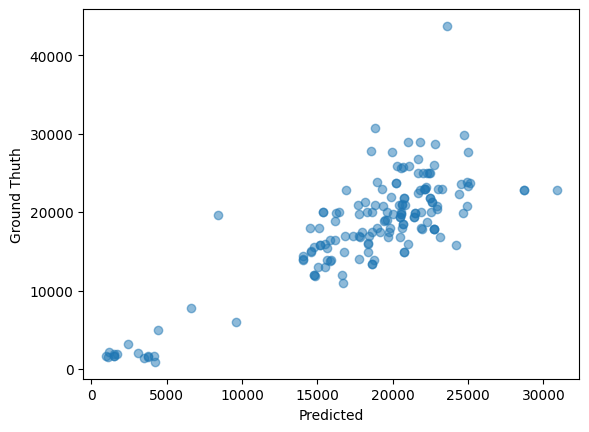

In [61]:
plt.scatter(model.predict(X_test), Y_test,  alpha=0.5)
plt.xlabel("Predicted")
plt.ylabel("Ground Thuth")